In [ ]:
import uiautomator2 as u2
import time
import PIL.Image as Image
d = u2.connect('127.0.0.1:5555')
def get_place(who=None, path=None):
        # time.sleep(0.2)
        img = d.screenshot(format='pillow')
        images = []  # 存儲待預測的圖像
        indices = []  # 存儲圖像的索引，以便在預測後進行結果的保存
        start_time = time.time()
        for i in range(0, 3):
            for j in range(0, 5):
                pointx = int(j * 62.7 + 144)
                pointy = i * 60 + 512

                img2 = img.crop((pointx - 30, pointy - 32,
                                pointx + 32, pointy + 30))
                # img2 = img2.convert('RGB')
                images.append(img2)
                indices.append((i, j))
                #顯示圖片
                img2.show()
get_place()

In [ ]:
import cv2
def get_place(who=None, path=None):
        # time.sleep(0.2)
        img = d.screenshot(format='opencv')
        images = []  # 存儲待預測的圖像
        indices = []  # 存儲圖像的索引，以便在預測後進行結果的保存
        start_time = time.time()
        for i in range(0, 3):
            for j in range(0, 5):
                pointx = int(j * 62.7 + 144)
                pointy = i * 60 + 562
                cv2.rectangle(img, (pointx - 30, pointy - 32),
                              (pointx + 32, pointy + 30), (0, 255, 0), 2)
        cv2.imshow('img', img)
        cv2.waitKey(0)
get_place()


In [ ]:
import uiautomator2 as u2
import time
import easyocr
import PIL.Image as Image
d = u2.connect('127.0.0.1:5555')
# reader=easyocr.Reader(['ch_tra'])



In [ ]:
start = time.time()
a=0
for i in range(0, 100):
    img =  d.screenshot(format='opencv')
stop = time.time()
print(stop-start)

In [ ]:
print((stop-start)/100)

In [ ]:
print(reader.readtext(img))


In [ ]:
import cv2
img = cv2.imread(r'C:\python_project\yinyun_auto_play_randomdice\dice_img\1.jpg')
cv2.imshow('img', img[:,50:])
cv2.waitKey(0)

In [ ]:
from bluestacks_fast_screenshot import get_bluestacks_screenshot
import cv2
blueit = get_bluestacks_screenshot(
    adb_path="C:\\platform-tools_r34.0.5-windows\\platform-tools\\adb.exe",
    deviceserial="127.0.0.1:5555",
    windowtitle="BlueStacks App Player",
    interpolation=cv2.INTER_AREA,
    ignore_exceptions=True,
    show_fps=True,
)

for pic in blueit:
    # do your stuff here
    cv2.imshow("", pic.copy())

    if cv2.waitKey(1) & 0xFF == ord("q"):
        cv2.destroyAllWindows()
        break

In [42]:
import win32gui
import win32ui
import win32con
import win32api
import subprocess
import numpy as np
import ctypes
import threading
from PIL import Image
from threading import Lock
def handle_find(name):
    handle = win32gui.FindWindow(None,name)
    if handle == 0:
        return False
    while(win32gui.FindWindowEx(handle, None, None, None)!=0):
        handle = win32gui.FindWindowEx(handle, None, None, None)
    return handle



class img_tools:
    def __init__(self,  handle,devices_ip):
        self.devices_ip = devices_ip
        self.handle = handle

        self.zoom = self.get_dpi_scaling_factor()
        self.left, self.top, self.width, self.height = self.get_windows_high_and_width()
        self.device_width, self.device_height = self.get_screen_size()
        self.lock=Lock()
        self.setting_screen()
        #開啟一個新的線程，用來更新畫面
        self.thread = threading.Thread(target=self.look)
        self.thread.start()
    def get_windows_high_and_width(self):
        left, top, right, bottom = win32gui.GetWindowRect(self.handle)
        width = right - left
        height = bottom - top
        return left, top,width,height
    def look(self):
        # 获取初始窗口大小
        rect = ctypes.wintypes.RECT()
        ctypes.windll.user32.GetWindowRect(self.handle, ctypes.byref(rect))
        initial_width = rect.right - rect.left
        initial_height = rect.bottom - rect.top

        while True:
            # 定期检查窗口大小是否发生变化
            ctypes.windll.user32.GetWindowRect(self.handle, ctypes.byref(rect))
            current_width = rect.right - rect.left
            current_height = rect.bottom - rect.top

            if current_width != initial_width or current_height != initial_height:
                print("Window size changed")
                initial_width = current_width
                initial_height = current_height
                print("New size: {}x{}".format(current_width, current_height))
                #上鎖
                self.lock.acquire()
            time.sleep(0.1)  # 等待一段时间再次检查窗口大小


    def setting_screen(self):
        self.hwndDC = win32gui.GetWindowDC(self.handle)
        self.mfcDC = win32ui.CreateDCFromHandle(self.hwndDC)
        self.saveDC = self.mfcDC.CreateCompatibleDC()
        self.saveBitMap = win32ui.CreateBitmap()
        self.saveBitMap.CreateCompatibleBitmap(self.mfcDC, self.width, self.height)
        self.saveDC.SelectObject(self.saveBitMap)
    def del_setting_screen(self):
        self.saveDC.DeleteDC()
        win32gui.DeleteObject(self.saveBitMap.GetHandle())
        self.mfcDC.DeleteDC()
        win32gui.ReleaseDC(self.handle, self.hwndDC)

    def update_screen(self):
        while(win32gui.FindWindowEx(self.handle, None, None, None)!=0):
            self.left, self.top, self.width, self.height = self.get_windows_high_and_width()
            print('更新畫面')
            self.del_setting_screen()
            self.setting_screen()

    def get_screen_size(self):
        '''return screen size width and high'''
        adb_command = ["adb" ,"-s",self.devices_ip, "shell", "wm", "size"]
        try:
            output = subprocess.check_output(adb_command)
            output = output.decode("utf-8").strip()
            width,height = output.split()[-1].split("x",1)
            return width,height
        except subprocess.CalledProcessError as e:
            print("Error:", e)
            return None

    def get_dpi_scaling_factor(self):
        try:
            ctypes.windll.shcore.SetProcessDpiAwareness(2)  # 设置DPI感知级别
            dpi_scaling_factor = ctypes.windll.shcore.GetScaleFactorForDevice(0) / 100.0
            return dpi_scaling_factor
        except Exception as e:
            print(f"获取缩放因子出错: {e}")
            return None

    def get_img(self,format='opencv'):
        if self.lock.locked():
            print('上鎖中，請稍後再試')
            #更新畫面
            self.left, self.top, self.width, self.height = self.get_windows_high_and_width()
            self.setting_screen()
            self.update_screen()
            self.lock.release()

        self.saveDC.BitBlt((0, 0), (int(self.width*self.zoom), int(self.height*self.zoom)), self.mfcDC, (0, 0), win32con.SRCCOPY)
        bmpinfo = self.saveBitMap.GetInfo()
        bmpstr = self.saveBitMap.GetBitmapBits(True)
        image = Image.frombuffer(
            'RGB',
            (bmpinfo['bmWidth'], bmpinfo['bmHeight']),
            bmpstr, 'raw', 'BGRX', 0, 1
        )
        #縮放至螢幕大小
        image = image.resize((int(self.device_width), int(self.device_height)), Image.Resampling.LANCZOS)
        if format=='opencv':
            return cv2.cvtColor(np.asarray(image), cv2.COLOR_RGB2BGR)
        elif format=='pillow':
            return image



In [44]:
import cv2
import time
handle = handle_find('BlueStacks App Player')
img_tool = img_tools(handle,'127.0.0.1:5565')
start=time.time()
for i in range(0, 100):
    img = img_tool.get_img()
stop=time.time()
print((stop-start))
# cv2.imshow('img', img)
# cv2.waitKey(0)

1.0355474948883057


In [ ]:
print(img_tool.handle)

上鎖中，請稍後再試


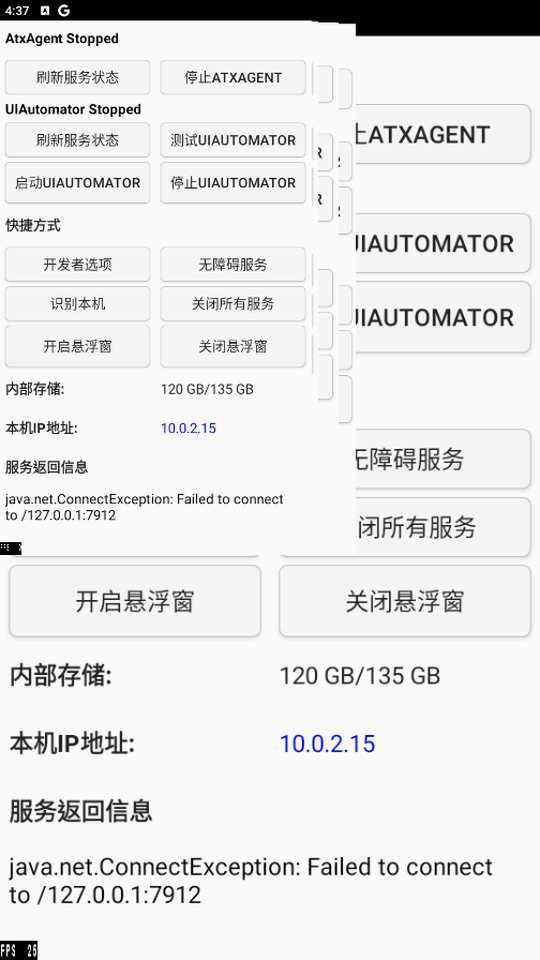

In [30]:
img = img_tool.get_img(format='pillow')
img

In [ ]:
import ctypes
import time

# 获取指定窗口句柄
window_handle = ctypes.windll.user32.FindWindowW(None, "BlueStacks App Player")



In [ ]:
import win32gui
import win32con
import time

def on_window_size_change(hwnd, msg, wparam, lparam):
    if msg == win32con.WM_SIZE:
        width = lparam & 0xFFFF
        height = (lparam >> 16) & 0xFFFF
        print(f"Window size changed to: {width}x{height}")

# 安装钩子
win32gui.SetWindowsHookEx(win32con.WH_CALLWNDPROC, on_window_size_change, 0, 0)

# 主循环，使程序保持运行
while True:
    time.sleep(1)


In [ ]:
import uiautomator2 as u2
d = u2.connect('127.0.0.1:5565')


In [ ]:
d.screenshot()

In [ ]:

import subprocess

def get_screen_size(ip):
    '''return screen size width and height'''
    adb_command = ["adb", "-s", ip, "shell", "wm", "size"]
    try:
        output = subprocess.check_output(adb_command)
        output = output.decode("utf-8").strip()
        width, height = output.split()[-1].split("x", 1)
        return width, height
    except subprocess.CalledProcessError as e:
        print("Error:", e)
        return None

adb_ip = '127.0.0.1:5565'
print(get_screen_size(adb_ip))


In [ ]:
import ctypes
import ctypes.wintypes
import time
import threading

def monitor_window_size(window_title):
    window_handle = ctypes.windll.user32.FindWindowW(None, window_title)
    if not window_handle:
        print("Window not found")
        return

    rect = ctypes.wintypes.RECT()
    ctypes.windll.user32.GetWindowRect(window_handle, ctypes.byref(rect))
    initial_width = rect.right - rect.left
    initial_height = rect.bottom - rect.top

    def check_window_size():
        nonlocal initial_width, initial_height
        while True:
            ctypes.windll.user32.GetWindowRect(window_handle, ctypes.byref(rect))
            current_width = rect.right - rect.left
            current_height = rect.bottom - rect.top

            if current_width != initial_width or current_height != initial_height:
                print("Window size changed")
                initial_width = current_width
                initial_height = current_height
                # 在这里可以添加通知或者其他操作

            time.sleep(1)  # 等待一段时间再次检查窗口大小

    # 启动一个线程来持续检查窗口大小变化
    monitor_thread = threading.Thread(target=check_window_size)
    monitor_thread.daemon = True  # 设置为守护线程，程序退出时自动关闭线程
    monitor_thread.start()

# 使用函数并指定窗口标题来开始监视窗口大小的变化
monitor_window_size("BlueStacks App Player")

# 这里可以添加其他代码或者让程序保持运行状态，以便线程能够持续监视窗口大小的变化
while True:
    pass